In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Settings
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


In [4]:
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')


In [5]:
# Quick Look
print(f"Customers: {customers.shape}")
print(f"Orders: {orders.shape}")
print(f"Items: {items.shape}")
print(f"Payments: {payments.shape}")
print(f"Reviews: {reviews.shape}")
print(f"Products: {products.shape}")
print(f"Sellers: {sellers.shape}")

Customers: (99441, 5)
Orders: (99441, 8)
Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)


In [6]:
# ════════════════════════════════════════════════════════════
# CUSTOMERS — LOOK AT DATA (7 Steps)
# ════════════════════════════════════════════════════════════

print("CUSTOMERS — INSPECTION")
print("="*70)
# 1. Shape
print (f"Shape: {customers.shape}")

# 2. Head
print(f"\n2. First 5 rows:")
display(customers.head())

# 3. Tail
print(f"\n3. Last 5 rows:")
display(customers.tail())

# 4. Info (MOST IMPORTANT!)
print(f"\n4. Column Info:")
customers.info()

# 5. Describe (if numeric columns exist)
if len(customers.select_dtypes(include=[np.number]).columns) > 0:
    print(f"\n5. Numeric Summary:")
    display(customers.describe())

# 6. Missing values
print(f"\n6. Missing Values:")
print(customers.isnull().sum())

# 7. Duplicates
print(f"\n7. Duplicates: {customers.duplicated().sum()}")

# 8. Text columns — value_counts (check for typos)

print(f"\n8. City Distribution (Top 10):")
print(customers['customer_city'].value_counts().head(10))

print(f"\n State Distribution:")
print(customers['customer_state'].value_counts())


CUSTOMERS — INSPECTION
Shape: (99441, 5)

2. First 5 rows:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



3. Last 5 rows:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS
99440,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,cotia,SP



4. Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB

5. Numeric Summary:


,customer_zip_code_prefix
count,99441.00
mean,35137.47
std,29797.94
min,1003.00
25%,11347.00
50%,24416.00
75%,58900.00
max,99990.00



6. Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

7. Duplicates: 0

8. City Distribution (Top 10):
customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64

 State Distribution:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64


In [7]:
# ════════════════════════════════════════════════════════════
# CUSTOMERS — CLEAN DATA (12 Steps)
# ════════════════════════════════════════════════════════════

print("🧹 CUSTOMERS — CLEANING")
print("="*70)

# STEP 1: Duplicates
before = len(customers)
customers = customers.drop_duplicates()
print(f"1. Duplicates removed: {before - len(customers)}")

# STEP 2: Hidden missing
customers = customers.replace(['N/A', 'null', 'None', '-', '', '?'], np.nan)
print(f"2. Hidden missing converted to NaN")

# STEP 3: Missing check
print(f"\n3. Missing values after conversion:")
print(customers.isnull().sum())

# STEP 4: Fill/Drop missing
# (No critical missing values expected, but if customer_id is missing, drop)
customers = customers.dropna(subset=['customer_id'])
print(f"4. Rows with missing customer_id dropped")

# STEP 5: Text clean
customers['customer_city'] = customers['customer_city'].str.strip().str.lower()
customers['customer_state'] = customers['customer_state'].str.strip().str.upper()
print(f"5. Text cleaned (city: lowercase, state: uppercase)")

# STEP 6: Reset index
customers = customers.reset_index(drop=True)
print(f"6. Index reset")

# STEP 7: Verify
print(f"\n✅ CUSTOMERS CLEANED!")
print(f"   Final shape: {customers.shape}")
print(f"   Missing values: {customers.isnull().sum().sum()}")
print(f"   Duplicates: {customers.duplicated().sum()}")

🧹 CUSTOMERS — CLEANING
1. Duplicates removed: 0
2. Hidden missing converted to NaN

3. Missing values after conversion:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
4. Rows with missing customer_id dropped
5. Text cleaned (city: lowercase, state: uppercase)
6. Index reset

✅ CUSTOMERS CLEANED!
   Final shape: (99441, 5)
   Missing values: 0
   Duplicates: 0


In [8]:
# ════════════════════════════════════════════════════════════
# ORDERS — LOOK AT DATA (7 Steps)
# ════════════════════════════════════════════════════════════

print(" ORDERS — INSPECTION")
print("="*70)

# 1. Shape
print(f"1. Shape: {orders.shape}")

# 2. Head
print(f"\n2. First 5 rows:")
display(orders.head())

# 3. Tail
print(f"\n3. Last 5 rows:")
display(orders.tail())

# 4. Info
print(f"\n4. Column Info:")
orders.info()

# 5. Describe
print(f"\n5. Numeric Summary:")
display(orders.describe())

# 6. Missing values
print(f"\n6. Missing Values:")
print(orders.isnull().sum())

# 7. Duplicates
print(f"\n7. Duplicates: {orders.duplicated().sum()}")

# 8. Value counts
print(f"\n8. Order Status Distribution:")
print(orders['order_status'].value_counts())

 ORDERS — INSPECTION
1. Shape: (99441, 8)

2. First 5 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



3. Last 5 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00
99440,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03 00:00:00



4. Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB

5. Numeric Summary:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522



6. Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

7. Duplicates: 0

8. Order Status Distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [9]:
# ════════════════════════════════════════════════════════════
# ORDERS — CLEAN DATA (12 Steps)
# ════════════════════════════════════════════════════════════
print("🧹 ORDERS — CLEANING")
print("="*70)

# STEP 1: Duplicates
before = len(orders)
orders = orders.drop_duplicates()
print(f"1. Duplicates removed: {before - len(orders)}")

# STEP 2: Unnecessary rows (keep only delivered)
'''🔹 Query structure
df = df[condition].copy()

🔹 তোমার case
orders = orders[orders['order_status'] == 'delivered'].copy()'''

before = len(orders)
orders = orders[orders['order_status'] == 'delivered'].copy()
print(f"2. Non-delivered orders removed: {before - len(orders)}")

# STEP 3: Hidden missing
orders = orders.replace(['N/A', 'null', 'None', '-', '', '?'], np.nan)

# STEP 4: Missing check
print(f"\n3. Missing values:")
print(orders.isnull().sum())

# STEP 5: Drop rows with missing delivery date
before = len(orders)
orders = orders.dropna(subset=['order_delivered_customer_date'])
print(f"4. Rows with missing delivery date dropped: {before - len(orders)}")

# STEP 6: Date fix
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')
print(f"5. Date columns converted to datetime")


# STEP 7: Fix impossible dates
before = len(orders)
orders = orders[orders['order_delivered_customer_date'] >= orders['order_purchase_timestamp']].copy()
print(f"6. Impossible dates removed: {before - len(orders)}")

# STEP 8: Reset index
orders = orders.reset_index(drop=True)

# STEP 12: Verify
print(f"\n✅ ORDERS CLEANED!")
print(f"   Final shape: {orders.shape}")
print(f"   Date range: {orders['order_purchase_timestamp'].min().date()} to {orders['order_purchase_timestamp'].max().date()}")
print(f"   Missing: {orders.isnull().sum().sum()}")

🧹 ORDERS — CLEANING
1. Duplicates removed: 0
2. Non-delivered orders removed: 2963

3. Missing values:
order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64
4. Rows with missing delivery date dropped: 8
5. Date columns converted to datetime
6. Impossible dates removed: 0

✅ ORDERS CLEANED!
   Final shape: (96470, 8)
   Date range: 2016-09-15 to 2018-08-29
   Missing: 15


In [10]:
# ════════════════════════════════════════════════════════════
# ORDERS — CREATE NEW COLUMNS
# ════════════════════════════════════════════════════════════
print("🔧 ORDERS — FEATURE ENGINEERING")
print("="*70)

# Math columns — Delivery metrics
orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
orders['estimated_days'] = (orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']).dt.days
orders['days_diff'] = (orders['order_delivered_customer_date'] -  orders['order_estimated_delivery_date']).dt.days

# Simple IF-ELSE — np.where (2 options)
orders['is_late'] = np.where(orders['days_diff'] > 0, 1, 0)

# Multiple conditions — np.select (3+ options)
conditions = [
    orders['delivery_days'] <= 7,
    orders['delivery_days'] <= 14,
    orders['delivery_days'] <= 21
]
choices = ['Fast', 'Normal', 'Slow']
orders['delivery_speed'] = np.select(conditions, choices, default='Very Slow')

# Date parts
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders['order_year'] = orders['order_purchase_timestamp'].dt.year
orders['order_month'] = orders['order_purchase_timestamp'].dt.month
orders['order_month_name'] = orders['order_purchase_timestamp'].dt.month_name()
orders['order_day_name'] = orders['order_purchase_timestamp'].dt.day_name()
orders['hour'] = orders['order_purchase_timestamp'].dt.hour

# Time of day (np.select)
conditions = [
    (orders['hour'] >= 6) & (orders['hour'] < 12),
    (orders['hour'] >= 12) & (orders['hour'] < 18),
    (orders['hour'] >= 18) & (orders['hour'] < 22)
]
choices = ['Morning', 'Afternoon', 'Evening']
orders['time_of_day'] = np.select(conditions, choices, default='Night')

#. Day of week
orders['day_of_week'] = orders['order_purchase_timestamp'].dt.day_name()
orders['day_of_week_num'] = orders ['order_purchase_timestamp'].dt.dayofweek

print(f"✅ Features created:")
print(f"   Avg delivery: {orders['delivery_days'].mean():.1f} days")
print(f"   Late orders: {orders['is_late'].mean()*100:.1f}%")
print(f"   New columns: {len(orders.columns)}")


🔧 ORDERS — FEATURE ENGINEERING
✅ Features created:
   Avg delivery: 12.1 days
   Late orders: 6.8%
   New columns: 22


In [11]:
# ════════════════════════════════════════════════════════════
# PRODUCTS — LOOK AT DATA
# ════════════════════════════════════════════════════════════
print("PRODUCTS — INSPECTION")
print("="*70)

print(f"1. Shape: {products.shape}")

print(f"\n2. First 5 rows:")
display(products.head())
print(f"\n3. Last 5 rows:")
display(products.tail())

print(f"\n4. Info:")
products.info()

print(f"\n5. Numeric Summary:")
display(products.describe())

print(f"\n6. Missing Values:")
print(products.isnull().sum())

print(f"\n7. Duplicates: {products.duplicated().sum()}")

print(f"\n8. Category Distribution (Top 10):")
print(products['product_category_name'].value_counts().head(10))

PRODUCTS — INSPECTION
1. Shape: (32951, 9)

2. First 5 rows:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00



3. Last 5 rows:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.00,67.00,2.00,12300.00,40.00,40.00,40.00
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.00,971.00,1.00,1700.00,16.00,19.00,16.00
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.00,799.00,1.00,1400.00,27.00,7.00,27.00
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.00,156.00,2.00,700.00,31.00,13.00,20.00
32950,106392145fca363410d287a815be6de4,cama_mesa_banho,58.00,309.00,1.00,2083.00,12.00,2.00,7.00



4. Info:
<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB

5. Numeric Summary:


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.00,32341.00,32341.00,32949.00,32949.00,32949.00,32949.00
mean,48.48,771.50,2.19,2276.47,30.82,16.94,23.20
std,10.25,635.12,1.74,4282.04,16.91,13.64,12.08
min,5.00,4.00,1.00,0.00,7.00,2.00,6.00
25%,42.00,339.00,1.00,300.00,18.00,8.00,15.00
50%,51.00,595.00,1.00,700.00,25.00,13.00,20.00
75%,57.00,972.00,3.00,1900.00,38.00,21.00,30.00
max,76.00,3992.00,20.00,40425.00,105.00,105.00,118.00



6. Missing Values:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

7. Duplicates: 0

8. Category Distribution (Top 10):
product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64


In [12]:
products = products.rename(columns={
    'product_name_lenght': 'product_name_length',
    'product_description_lenght': 'product_description_length'
})

In [13]:
# ════════════════════════════════════════════════════════════
# PRODUCTS — CLEAN DATA
# ════════════════════════════════════════════════════════════
print("🧹 PRODUCTS — CLEANING")
print("="*70)

# Duplicates
products = products.drop_duplicates()

# Hidden missing
products = products.replace(['N/A', 'null', 'None', '-', '', '?'], np.nan)

# Fill missing — Category (text)
products['product_category_name'] = products['product_category_name'].fillna('unknown')

# Fill missing — Numeric (median)
numeric_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 
                'product_width_cm', 'product_name_length', 
                'product_description_length', 'product_photos_qty']
for col in numeric_cols:
    products[col] = products[col].fillna(products[col].median())

# Text clean
products['product_category_name'] = (products['product_category_name'].str.strip().str.lower().str.replace('_', ' '))

# Reset index
products = products.reset_index(drop=True)

print(f"✅ PRODUCTS CLEANED!")
print(f"   Shape: {products.shape}")
print(f"   Missing: {products.isnull().sum().sum()}")

🧹 PRODUCTS — CLEANING
✅ PRODUCTS CLEANED!
   Shape: (32951, 9)
   Missing: 0


In [14]:
# ════════════════════════════════════════════════════════════
# PRODUCTS — CREATE NEW COLUMNS
# ════════════════════════════════════════════════════════════
print("PRODUCTS — FEATURE ENGINEERING")
print("="*70)

# Math column — Volume
products['volume_cm3'] = (products['product_length_cm'] * products['product_height_cm'] * products['product_width_cm'])

# Category column — Weight category (np.select)
conditions = [
    products['product_weight_g'] <= 500,
    products['product_weight_g'] <= 2000,
    products['product_weight_g'] <= 10000
]
choices = ['Light', 'Medium', 'Heavy']
products['weight_category'] = np.select(conditions, choices, default='Very Heavy')

print(f"✅ Features created:")
print(f"   Avg volume: {products['volume_cm3'].mean():,.0f} cm³")
print(f"   Weight distribution:")
print(products['weight_category'].value_counts())

PRODUCTS — FEATURE ENGINEERING
✅ Features created:
   Avg volume: 16,563 cm³
   Weight distribution:
weight_category
Light         13576
Medium        11626
Heavy          5858
Very Heavy     1891
Name: count, dtype: int64


In [15]:
# ════════════════════════════════════════════════════════════
# ORDER ITEMS — LOOK + CLEAN + FEATURES
# ════════════════════════════════════════════════════════════
print(" ORDER ITEMS — INSPECTION")
print("="*70)

# LOOK
print(f"Shape: {items.shape}")
items.info()
print(f"\nMissing: {items.isnull().sum().sum()}")
print(f"Duplicates: {items.duplicated().sum()}")
print(f"\nPrice stats:")
print(items[['price', 'freight_value']].describe())

# CLEAN
print(f"\n🧹 CLEANING...")
items = items.drop_duplicates()
items = items[(items['price'] > 0) & (items['freight_value'] >= 0)].copy()
items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'], errors='coerce')
items = items.reset_index(drop=True)

# FEATURES
print(f"\n🔧 FEATURE ENGINEERING...")
items['total_price'] = items['price'] + items['freight_value']
items['freight_pct'] = np.where(items['price'] > 0, (items['freight_value'] / items['price'] * 100), 0)

print(f"\n✅ ITEMS COMPLETE!")
print(f"   Shape: {items.shape}")
print(f"   Avg total: R${items['total_price'].mean():.2f}")

 ORDER ITEMS — INSPECTION
Shape: (112650, 7)
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB

Missing: 0
Duplicates: 0

Price stats:
          price  freight_value
count 112650.00      112650.00
mean     120.65          19.99
std      183.63          15.81
min        0.85           0.00
25%       39.90          13.08
50%       74.99          16.26
75%      134.90          21.15
max     6735.00         409.68

🧹 CLEANING...

🔧 FE

In [16]:
# ════════════════════════════════════════════════════════════
# PAYMENTS — LOOK + CLEAN
# ════════════════════════════════════════════════════════════
print(" PAYMENTS — INSPECTION + CLEANING")
print("="*70)

# LOOK
print(f"Shape: {payments.shape}")
payments.info()
print(f"\nPayment Types:")
print(payments['payment_type'].value_counts())

# CLEAN
payments = payments.drop_duplicates()
payments['payment_type'] = payments['payment_type'].str.strip().str.lower()
payments = payments[payments['payment_value'] >= 0].copy()
payments = payments.reset_index(drop=True)

print(f"\n✅ PAYMENTS CLEANED!")
print(f"   Shape: {payments.shape}")

 PAYMENTS — INSPECTION + CLEANING
Shape: (103886, 5)
<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB

Payment Types:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

✅ PAYMENTS CLEANED!
   Shape: (103886, 5)


In [17]:
# ════════════════════════════════════════════════════════════
# REVIEWS — LOOK + CLEAN
# ════════════════════════════════════════════════════════════
print(" REVIEWS — INSPECTION + CLEANING")
print("="*70)

# LOOK
print(f"Shape: {reviews.shape}")
reviews.info()
print(f"\nReview Scores:")
print(reviews['review_score'].value_counts().sort_index())
print(f"\nMissing:")
print(reviews.isnull().sum())

# CLEAN
reviews = reviews.drop_duplicates()
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'], errors='coerce')
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'], errors='coerce')
reviews = reviews[(reviews['review_score'] >= 1) & (reviews['review_score'] <= 5)].copy()
reviews['review_comment_title'] = reviews['review_comment_title'].fillna('No Comment')
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('No Comment')
reviews = reviews.reset_index(drop=True)

print(f"\n✅ REVIEWS CLEANED!")
print(f"   Shape: {reviews.shape}")
print(f"   Avg score: {reviews['review_score'].mean():.2f}")

 REVIEWS — INSPECTION + CLEANING
Shape: (99224, 7)
<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB

Review Scores:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Missing:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timest

In [18]:
# ════════════════════════════════════════════════════════════
# SELLERS — LOOK + CLEAN
# ════════════════════════════════════════════════════════════
print("SELLERS — INSPECTION + CLEANING")
print("="*70)

# LOOK
print(f"Shape: {sellers.shape}")
sellers.info()
print(f"\nTop States:")
print(sellers['seller_state'].value_counts().head())

# CLEAN
sellers = sellers.drop_duplicates()
sellers['seller_city'] = sellers['seller_city'].str.strip().str.lower()
sellers['seller_state'] = sellers['seller_state'].str.strip().str.upper()
sellers = sellers.reset_index(drop=True)

print(f"\n✅ SELLERS CLEANED!")
print(f"   Shape: {sellers.shape}")

SELLERS — INSPECTION + CLEANING
Shape: (3095, 4)
<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB

Top States:
seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
Name: count, dtype: int64

✅ SELLERS CLEANED!
   Shape: (3095, 4)


In [19]:
# ════════════════════════════════════════════════════════════
# CELL 14: MERGE ALL TABLES → MASTER DATAFRAME
# ════════════════════════════════════════════════════════════
print("🔗 MERGING ALL TABLES...")
print("="*70)

# Step 1: Orders + Items
df = orders.merge(items, on='order_id', how='inner')
print(f"Step 1 — Orders + Items: {df.shape}")

# Step 2: + Products
df = df.merge(products, on='product_id', how='left')
print(f"Step 2 — + Products: {df.shape}")

# Step 3: + Customers
df = df.merge(customers, on='customer_id', how='left')
print(f"Step 3 — + Customers: {df.shape}")

# Step 4: + Payments (aggregate first!)
payment_agg = payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'max',
    'payment_type': 'first'
}).reset_index()
df = df.merge(payment_agg, on='order_id', how='left')
print(f"Step 4 — + Payments: {df.shape}")

# Step 5: + Reviews (aggregate first!)
review_agg = reviews.groupby('order_id').agg({
    'review_score': 'mean'
}).reset_index()
df = df.merge(review_agg, on='order_id', how='left')
print(f"Step 5 — + Reviews: {df.shape}")

# Step 6: + Sellers
df = df.merge(sellers, on='seller_id', how='left')
print(f"Step 6 — + Sellers: {df.shape}")

# Final summary
print(f"\n{'='*70}")
print(f"✅ MASTER DATAFRAME COMPLETE!")
print(f"   Shape: {df.shape}")
print(f"   Total Revenue: R${df['total_price'].sum():,.2f}")
print(f"   Total Orders: {df['order_id'].nunique():,}")
print(f"   Avg Review Score: {df['review_score'].mean():.2f}/5.0")


🔗 MERGING ALL TABLES...
Step 1 — Orders + Items: (110189, 30)
Step 2 — + Products: (110189, 40)
Step 3 — + Customers: (110189, 44)
Step 4 — + Payments: (110189, 47)
Step 5 — + Reviews: (110189, 48)
Step 6 — + Sellers: (110189, 51)

✅ MASTER DATAFRAME COMPLETE!
   Shape: (110189, 51)
   Total Revenue: R$15,418,394.83
   Total Orders: 96,470
   Avg Review Score: 4.08/5.0


In [20]:
print (df)

                                order_id                       customer_id  \
0       e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1       53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2       47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3       949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4       ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   
...                                  ...                               ...   
110184  63943bddc261676b46f01ca7ac2f7bd8  1fca14ff2861355f6e5f14306ff977a7   
110185  83c1379a015df1e13d02aae0204711ab  1aa71eb042121263aafbe80c1b562c9c   
110186  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
110187  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
110188  66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   

       order_status order_purchase_timestamp   order_approved_a

In [21]:
import os
os.makedirs('data/cleaned', exist_ok=True)

# Save
df.to_csv('data/cleaned/master_data_cleaned.csv', index=False)
print(f"\n💾 Saved: data/cleaned/master_data_cleaned.csv")


💾 Saved: data/cleaned/master_data_cleaned.csv


In [22]:
 print ("Python: EDA Part 1 (Revenue & Sales)")


Python: EDA Part 1 (Revenue & Sales)


In [23]:
## Revenue & Sales Analysis
# ---- CELL 13: KPI Summary ----
print("=" * 50)
print("📊 BUSINESS KPI SUMMARY")
print("=" * 50)
print(f"Total Revenue:        $ {df['total_price'].sum():,}")
print(f"Total Orders:         {df['order_id'].nunique():,}")
print(f"Total Customers:      {df['customer_unique_id'].nunique():,}")
print(f"Total Products:       {df['product_id'].nunique():,}")
print(f"Total Sellers:        {df['seller_id'].nunique():,}")
print(f"Avg Order Value:      $ {df.groupby('order_id')['total_price'].sum().mean():,.2f}")
print(f"Avg Review Score:     {df['review_score'].mean():.2f}")
print(f"Avg Delivery Days:    {df['delivery_days'].mean():.1f}")
print(f"Late Delivery %:      {df['is_late'].mean()*100:.1f}%")
print(f"Date Range:           {df['order_purchase_timestamp'].min().date()} to {df['order_purchase_timestamp'].max().date()}")




📊 BUSINESS KPI SUMMARY
Total Revenue:        $ 15,418,394.83
Total Orders:         96,470
Total Customers:      93,350
Total Products:       32,214
Total Sellers:        2,970
Avg Order Value:      $ 159.83
Avg Review Score:     4.08
Avg Delivery Days:    12.0
Late Delivery %:      6.6%
Date Range:           2016-09-15 to 2018-08-29


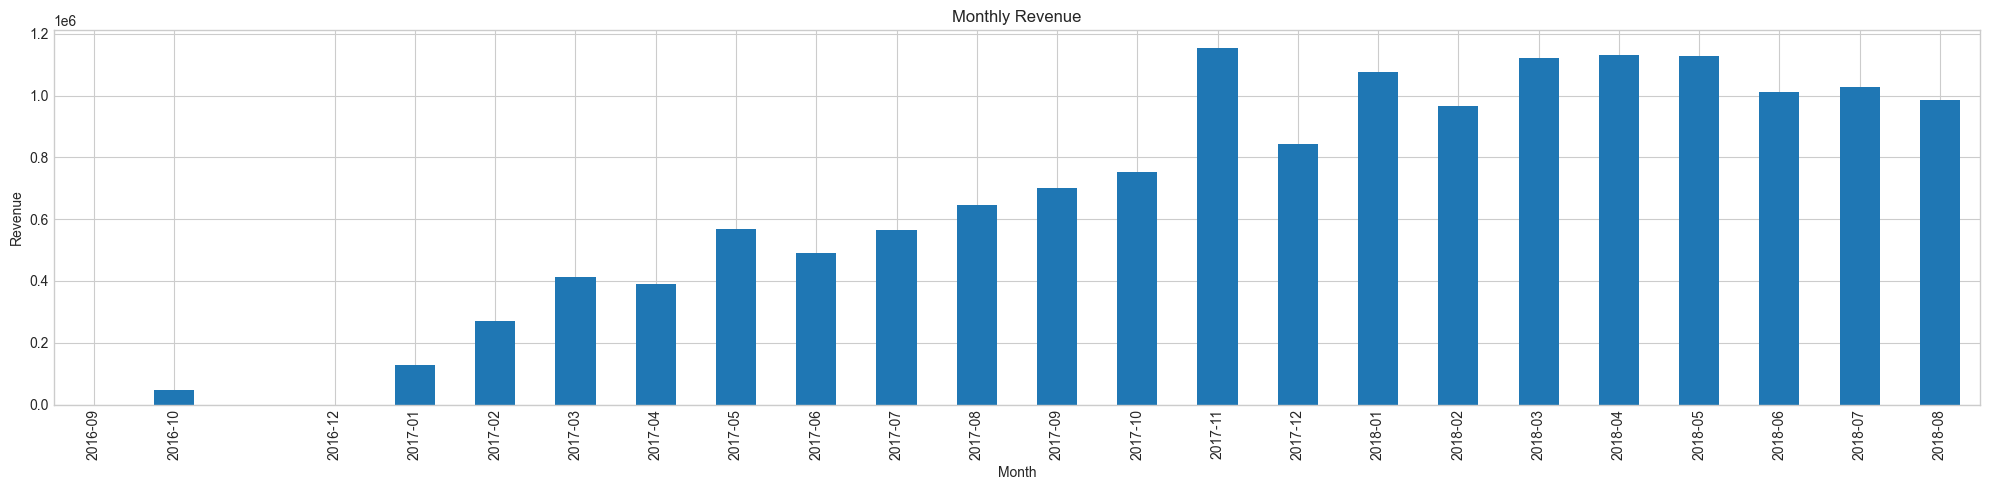

In [24]:
# CHART 1 — Monthly Revenue Trend ----
monthly_rev = df.groupby('year_month')['total_price'].sum().reset_index()
plt.figure(figsize=(20, 5))
monthly_rev.set_index('year_month')['total_price'].plot( kind='bar')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()



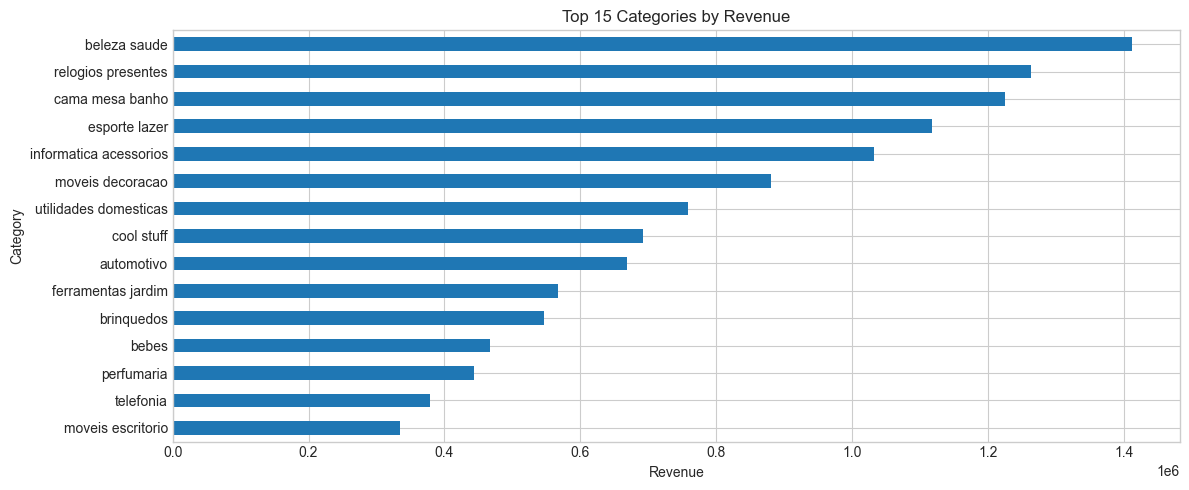

In [25]:
# CHART 2 — Top 15 Categories by Revenue ----
top_cate = df.groupby('product_category_name')['total_price'].sum().reset_index()
top_cate = top_cate.sort_values('total_price', ascending=True).tail(15)
plt.figure(figsize=(12, 5))
top_cate.set_index('product_category_name')['total_price'].plot(kind='barh')
plt.title('Top 15 Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


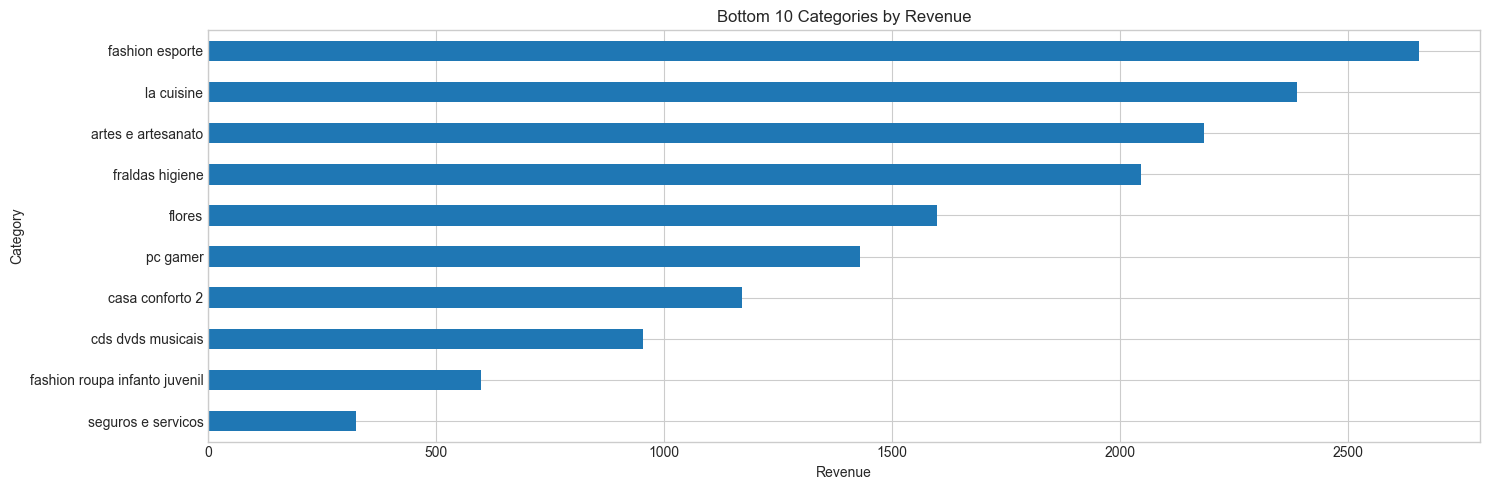

In [26]:
#CHART 3 — Bottom 10 Categories ----
bottom_cate = df.groupby('product_category_name')['total_price'].sum().reset_index()
bottom_cate = bottom_cate.sort_values('total_price').head(10)
plt.figure(figsize=(15, 5))
bottom_cate.set_index('product_category_name')['total_price'].plot(kind='barh')
plt.title('Bottom 10 Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

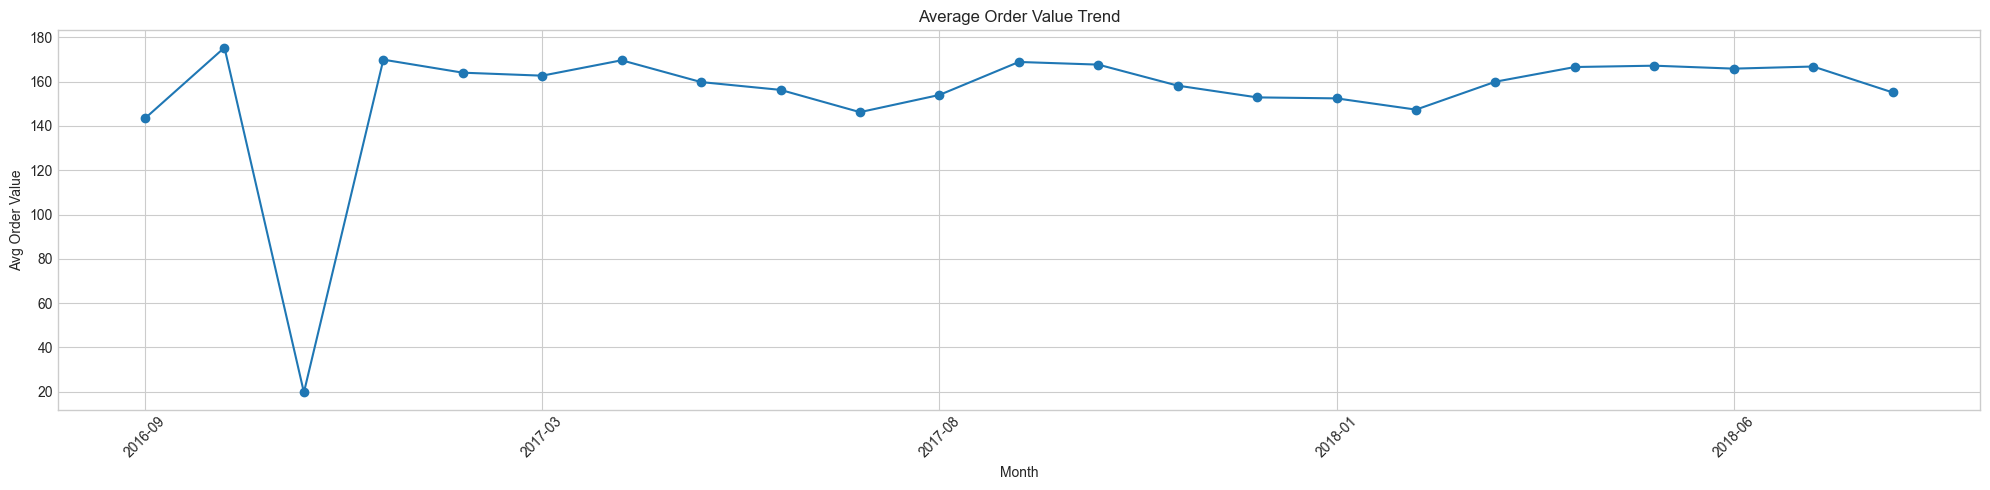

In [27]:
# 4 — Average Order Value Trend ----
monthly_aov = df.groupby('year_month').agg(total_revenue=('total_price', 'sum'),total_orders=('order_id', 'nunique')).reset_index()
monthly_aov['avg_order_value'] = monthly_aov['total_revenue'] / monthly_aov['total_orders']
monthly_aov['year_month'] = monthly_aov['year_month'].astype(str)
plt.figure(figsize=(20, 5))
monthly_aov.set_index('year_month')['avg_order_value'].plot(kind='line', marker='o')
plt.title('Average Order Value Trend')
plt.xlabel('Month')
plt.ylabel('Avg Order Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
monthly_aov = df.groupby('year_month').agg(total_revenue=('total_price', 'sum'),total_orders=('order_id', 'nunique')).reset_index()
monthly_aov['avg_order_value'] = monthly_aov['total_revenue'] / monthly_aov['total_orders']
monthly_aov['year_month'] = monthly_aov['year_month'].astype(str)
print(monthly_aov)

   year_month  total_revenue  total_orders  avg_order_value
0     2016-09         143.46             1           143.46
1     2016-10       46490.66           265           175.44
2     2016-12          19.62             1            19.62
3     2017-01      127482.37           750           169.98
4     2017-02      271239.32          1653           164.09
5     2017-03      414330.95          2546           162.74
6     2017-04      390812.40          2303           169.70
7     2017-05      566657.40          3545           159.85
8     2017-06      490050.37          3135           156.32
9     2017-07      566299.08          3872           146.25
10    2017-08      645832.36          4193           154.03
11    2017-09      701077.49          4150           168.93
12    2017-10      751117.01          4478           167.73
13    2017-11     1153229.37          7288           158.24
14    2017-12      843078.29          5513           152.93
15    2018-01     1077887.46          70

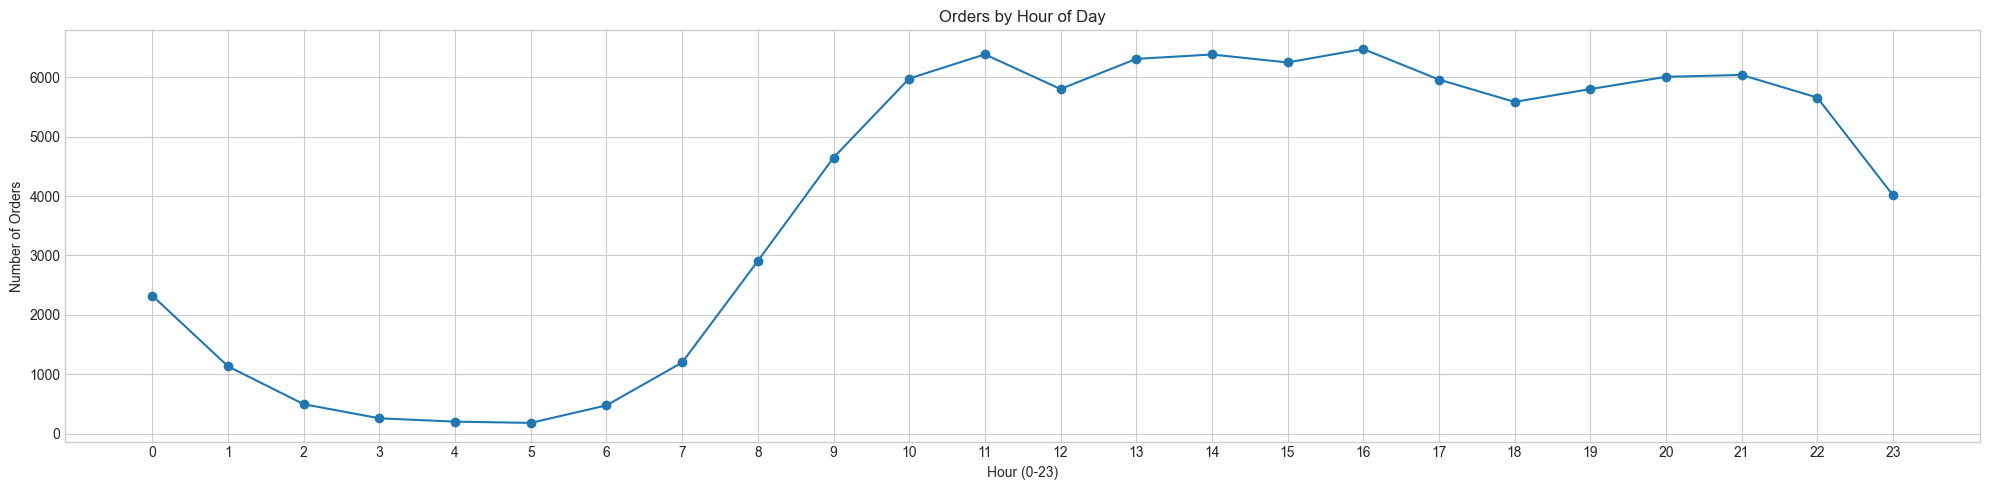

In [ ]:
#CHART 5 — Orders by Hour of Day ----
hour_data = df.groupby('hour')['order_id'].nunique()
plt.figure(figsize=(20, 5))
hour_data.plot(kind='line', marker='o')
plt.title('Orders by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

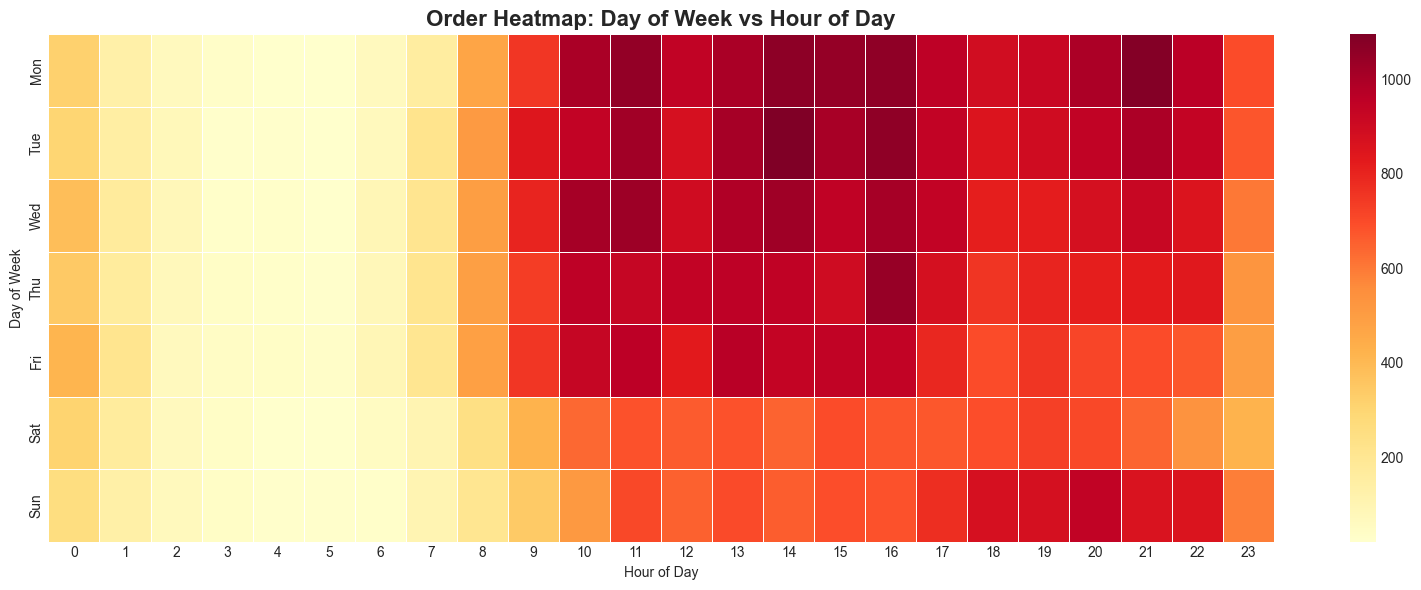

In [30]:
# CHART 6 — Orders by Hour of Day ----
day_hour = df.groupby(['day_of_week_num', 'hour'])['order_id'].nunique().reset_index()
day_hour_pivot = day_hour.pivot(index='day_of_week_num', columns='hour', values='order_id')
day_hour_pivot.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(day_hour_pivot, cmap='YlOrRd', annot=False,  fmt='.0f', linewidths=0.5, ax=ax)
ax.set_title('Order Heatmap: Day of Week vs Hour of Day',  fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.show()


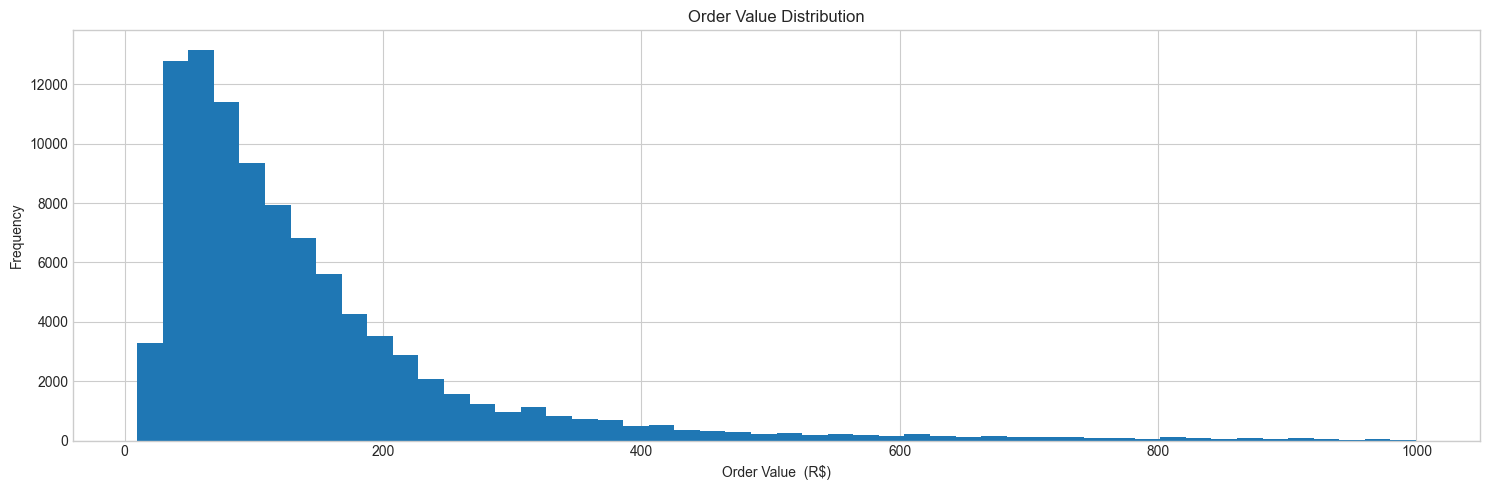

In [31]:
# CHART 7 — Revenue Distribution (Histogram)
order_totals = df.groupby('order_id')['total_price'].sum()
plt.figure(figsize=(15, 5))
order_totals[order_totals < 1000].plot(kind='hist', bins=50)
plt.title('Order Value Distribution')
plt.xlabel('Order Value  (R$)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

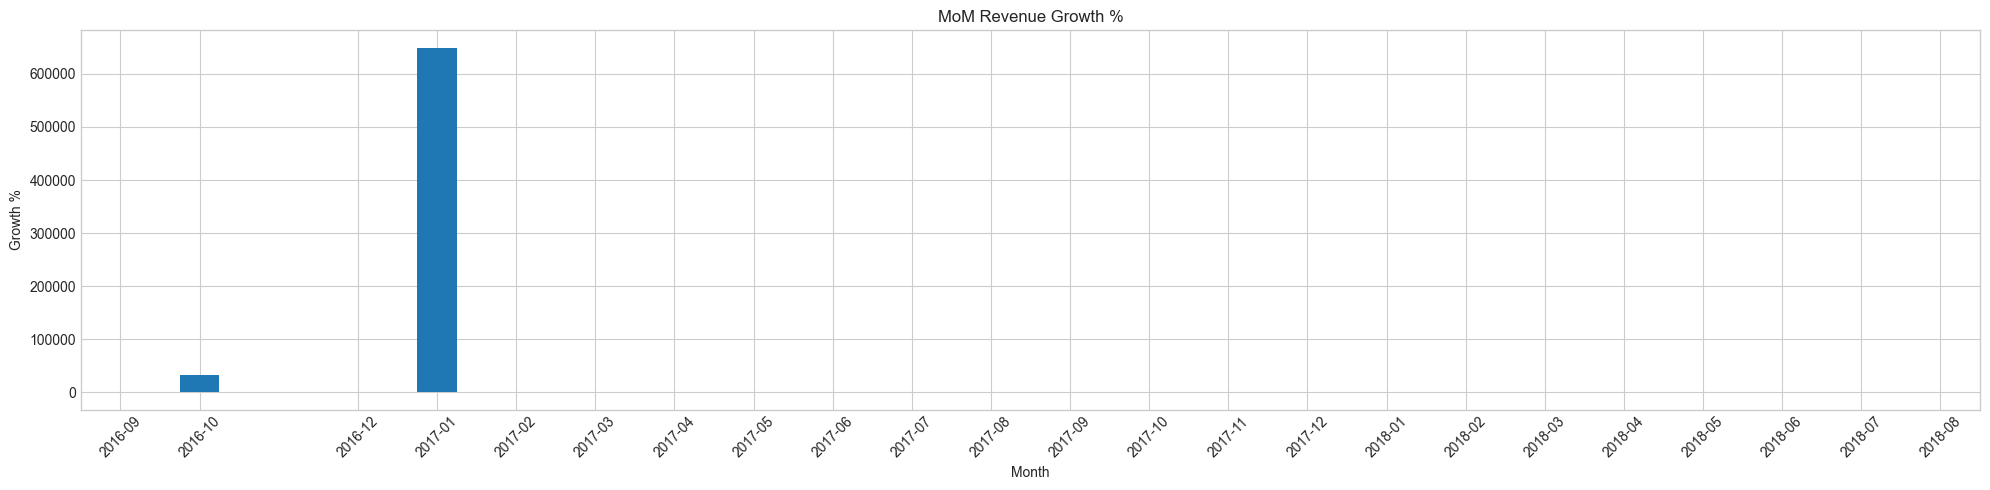

In [32]:
#CHART 8 — MoM Growth Rate ----
monthly_rev_growth = monthly_rev.copy()
monthly_rev_growth['growth_pct'] = (monthly_rev_growth['total_price'].pct_change() * 100)
plt.figure(figsize=(20, 5))
monthly_rev_growth.set_index('year_month')['growth_pct'].fillna(0).plot(kind='bar')
plt.title('MoM Revenue Growth %')
plt.xlabel('Month')
plt.ylabel('Growth %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

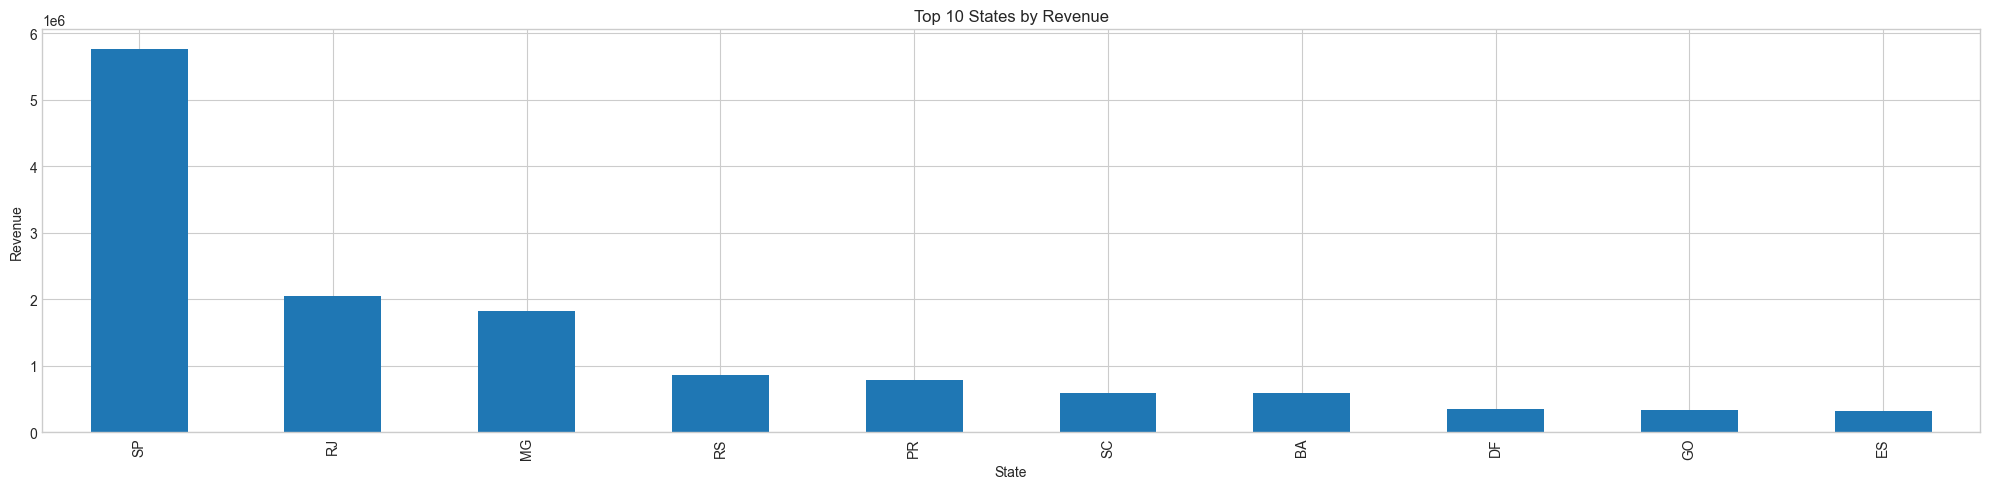

In [82]:
# CHART 9 — Top 10 States by Revenue ----
state_rev = df.groupby('customer_state').agg(
    revenue=('total_price', 'sum'),
    orders=('order_id', 'nunique'),
    customers=('customer_unique_id', 'nunique')
).sort_values('revenue', ascending=False).head(10)
plt.figure(figsize=(20, 5))
state_rev['revenue'].plot(kind='bar')
plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

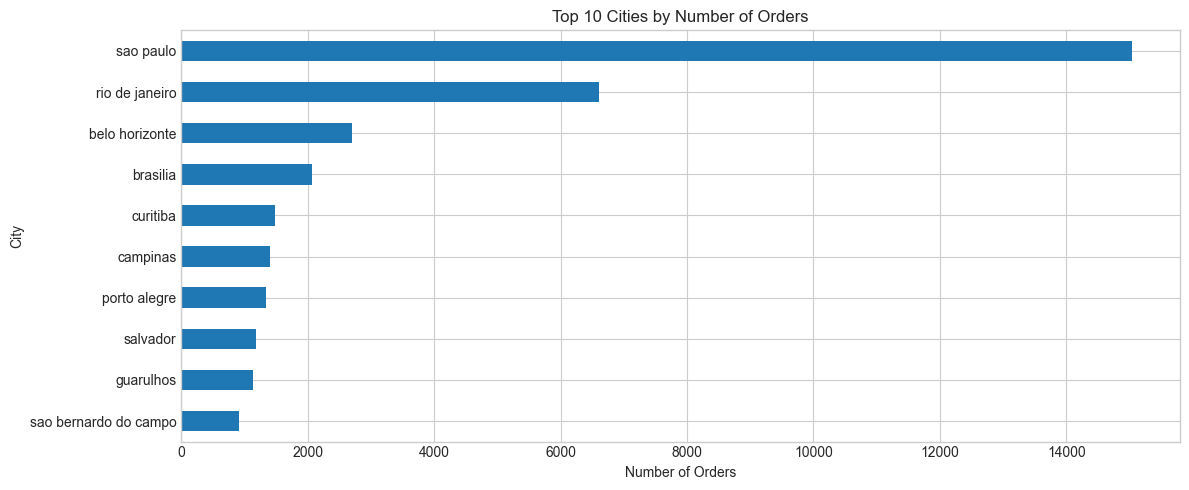

In [79]:
#CHART 10 — Top 10 Cities ----
city_rev = df.groupby('customer_city')['order_id'].nunique().sort_values().tail(10)
plt.figure(figsize=(12, 5))
city_rev.plot(kind='barh')
plt.title('Top 10 Cities by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('City')
plt.tight_layout()
plt.show()

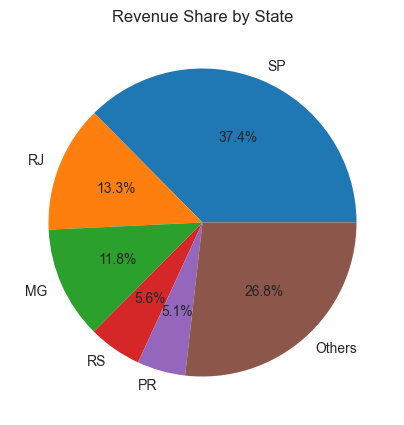

In [35]:
#CHART 11 — State Revenue Share (Pie) ----
state_all = df.groupby('customer_state')['total_price'].sum()
top_5 = state_all.nlargest(5)
others = state_all.sum() - top_5.sum()
pie_data = pd.concat([top_5, pd.Series({'Others': others})])
plt.figure(figsize=(5, 5))
pie_data.plot(kind='pie', autopct='%1.1f%%')
plt.title('Revenue Share by State')
plt.ylabel('')
plt.show()

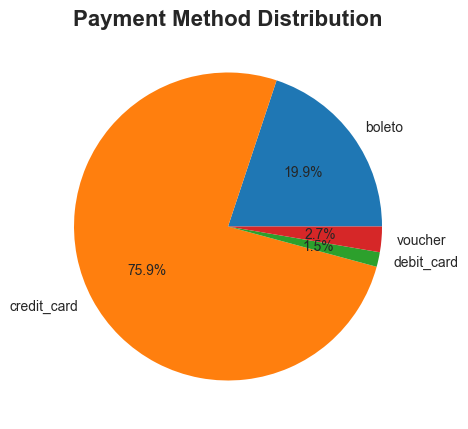

In [78]:
# CHART 12 — Payment Method Distribution ----
pay_dist = df.groupby('payment_type')['order_id'].nunique()
plt.figure(figsize=(5, 5))
pay_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Method Distribution', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.show()

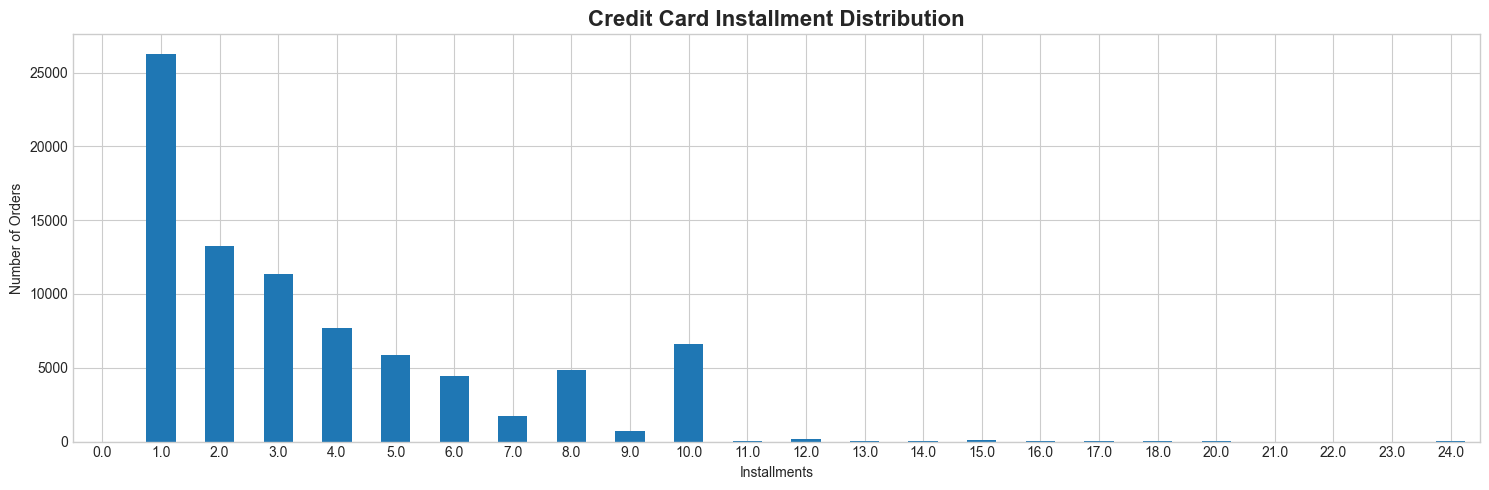

In [37]:
#CHART 13 — Payment Installments ----
installment_data = df[df['payment_type'] == 'credit_card']['payment_installments'].value_counts().sort_index()
plt.figure(figsize=(15, 5))
installment_data.plot(kind='bar')
plt.title('Credit Card Installment Distribution',fontsize=16, fontweight='bold')
plt.xlabel('Installments')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

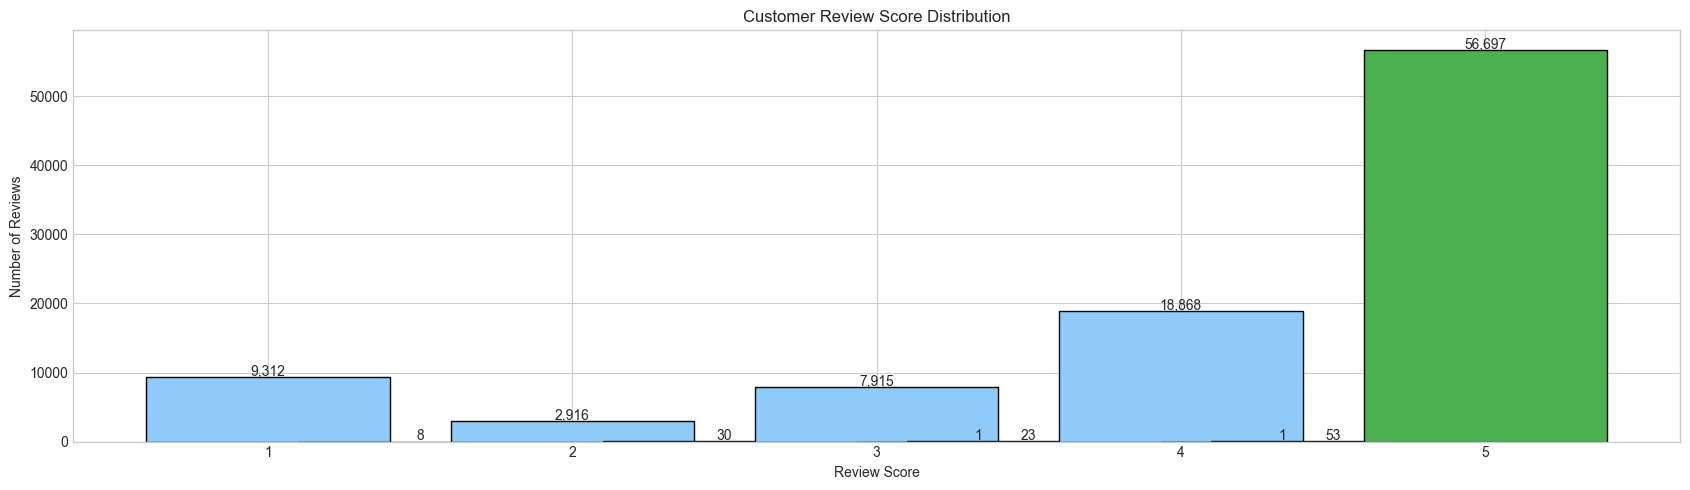

In [38]:
#CHART 14 — Review Score Distribution
review_dist = df.groupby('order_id')['review_score'].first().value_counts().sort_index()
plt.figure(figsize=(17, 5))
colors = ['#4CAF50' if x == review_dist.max() else '#90CAF9' for x in review_dist.values]
plt.bar(review_dist.index, review_dist.values, color=colors, edgecolor='black')
# value labels
for i, v in enumerate(review_dist.values):
    plt.text(review_dist.index[i], v + 200, f'{v:,}', ha='center')
plt.title('Customer Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

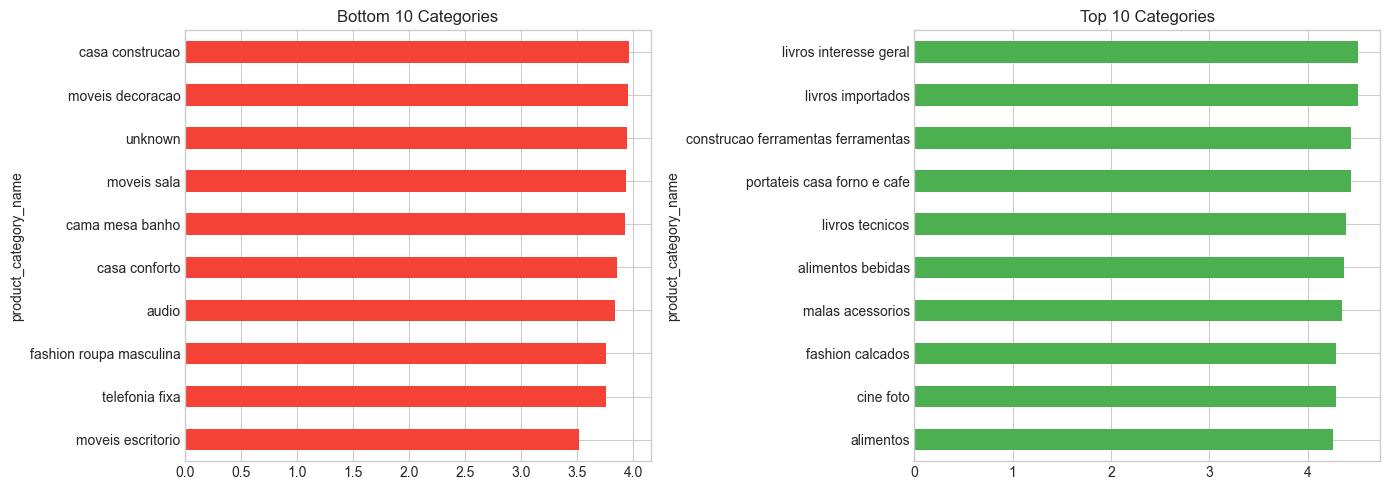

In [39]:
#CHART 15 — Avg Review by Top/Bottom Categories ----
cat_review = df.groupby('product_category_name')['review_score'].mean()
cat_review = cat_review[df.groupby('product_category_name')['review_score'].count() > 50]
cat_review = cat_review.sort_values()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_review.head(10).plot(kind='barh', ax=axes[0],color='#F44336')
axes[0].set_title('Bottom 10 Categories')

cat_review.tail(10).plot(kind='barh', ax=axes[1],color='#4CAF50')
axes[1].set_title('Top 10 Categories')

plt.tight_layout()
plt.show()

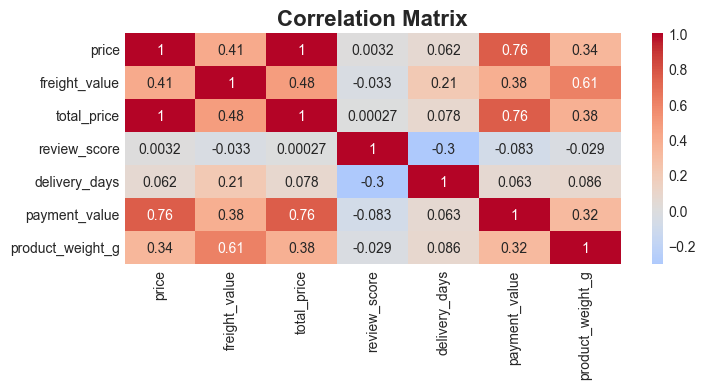

In [40]:
# CHART 16 — Correlation Heatmap ----
corr_cols = ['price', 'freight_value', 'total_price',
             'review_score', 'delivery_days',
             'payment_value', 'product_weight_g']

corr_matrix = df[corr_cols].corr()
plt.figure(figsize=(8, 3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix',fontsize=16, fontweight='bold')
plt.show()
# 📌 Insight: Strong positive correlation between weight and freight.
# Negative  correlation between delivery_days and review_score.


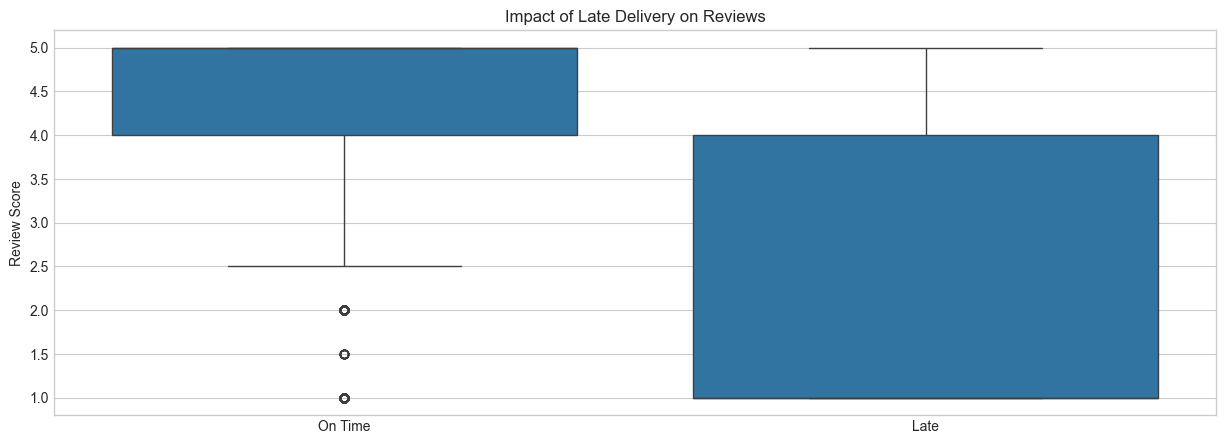

In [41]:
#CHART 17 — Late Delivery vs Review Score ----
plt.figure(figsize=(15, 5))
sns.boxplot(x='is_late', y='review_score', data=df)
plt.xticks([0, 1], ['On Time', 'Late'])
plt.title('Impact of Late Delivery on Reviews')
plt.xlabel('')
plt.ylabel('Review Score')
plt.show()

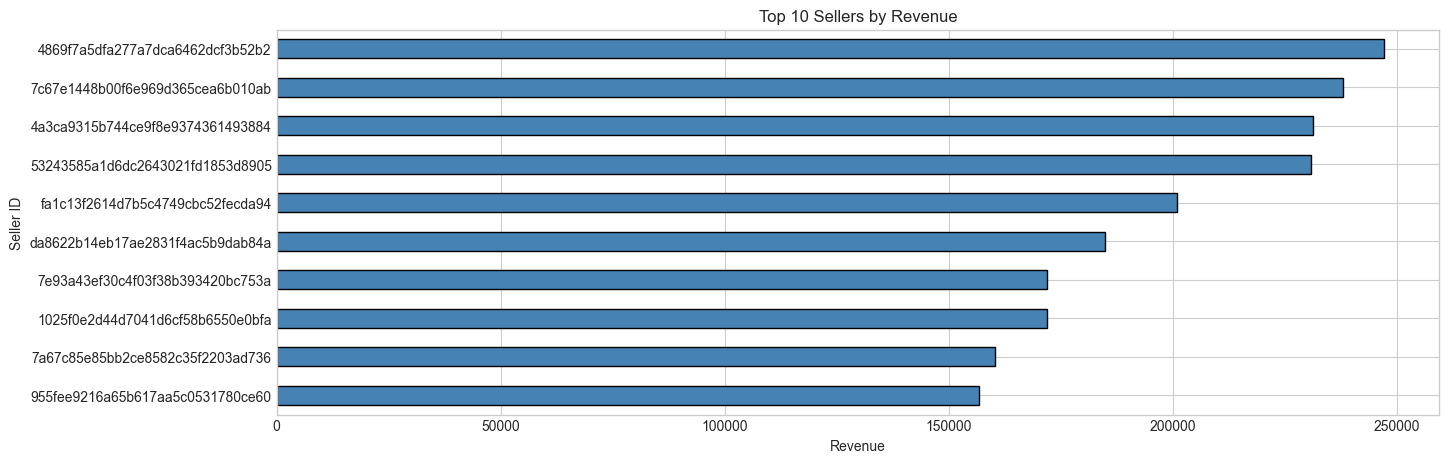

In [77]:
#CHART 18 ---- Top Sellers by Revenue ----
seller_rev = df.groupby('seller_id')['total_price'].sum().sort_values().tail(10)
plt.figure(figsize=(15, 5))
seller_rev.plot(kind='barh',color='steelblue',edgecolor='black')
plt.title('Top 10 Sellers by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Seller ID')
plt.show()

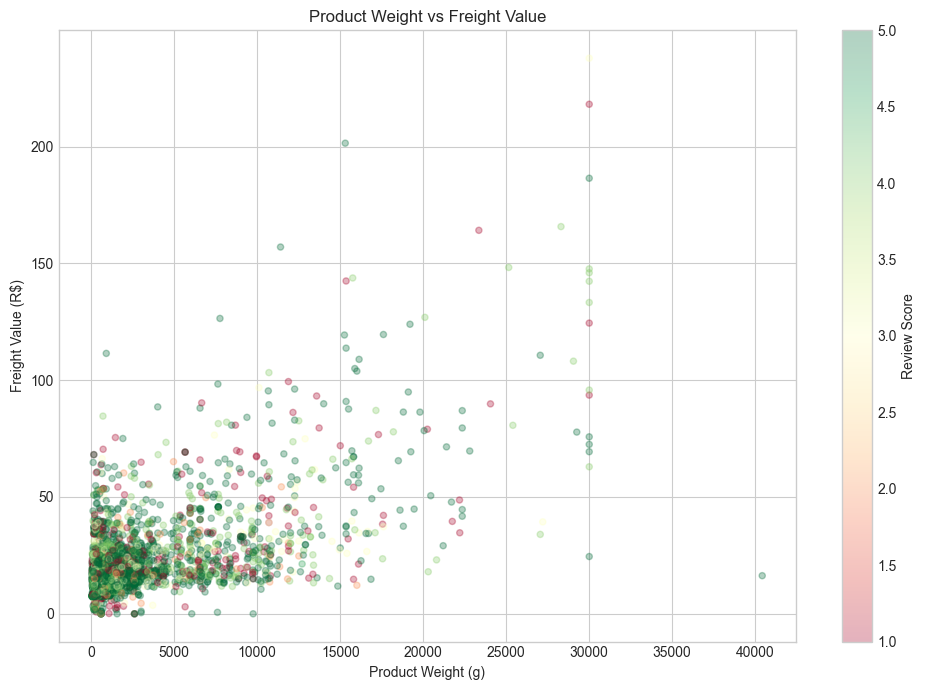

In [43]:
# ---- CHART 19: Freight vs Product Weight (Scatter) ----
sample = df.sample(5000, random_state=42)
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(sample['product_weight_g'],sample['freight_value'],alpha=0.3,c=sample['review_score'],cmap='RdYlGn',s=20)

plt.colorbar(scatter, label='Review Score')
ax.set_title('Product Weight vs Freight Value')
ax.set_xlabel('Product Weight (g)')
ax.set_ylabel('Freight Value (R$)')
plt.tight_layout()
plt.show()

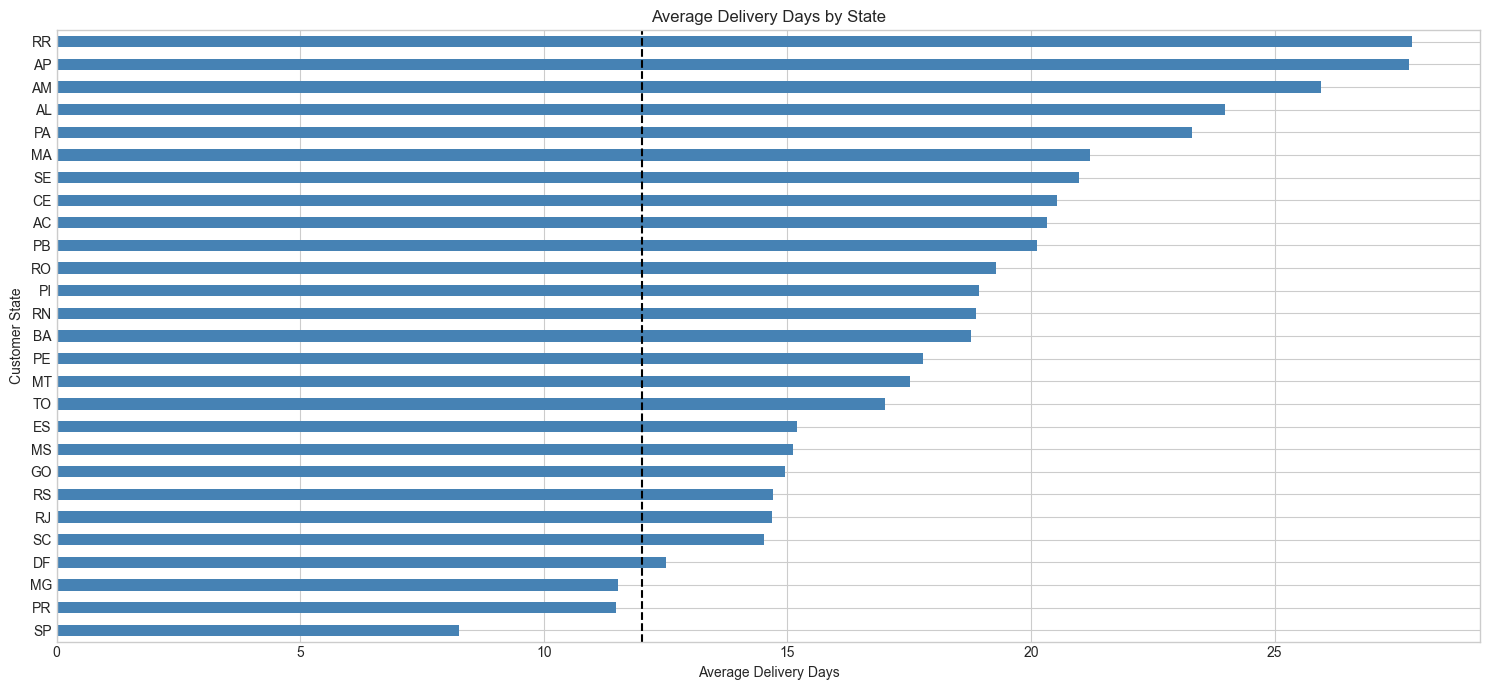

In [83]:
# ---- CHART 23: Delivery Days by State ----
state_delivery = df.groupby('customer_state')['delivery_days'].mean().sort_values(ascending=True)
plt.figure(figsize=(15, 7))
state_delivery.plot(kind='barh',color='steelblue')
plt.axvline(df['delivery_days'].mean(), color='black', linestyle='--')
plt.title('Average Delivery Days by State')
plt.xlabel('Average Delivery Days')
plt.ylabel('Customer State')

plt.tight_layout()
plt.show()

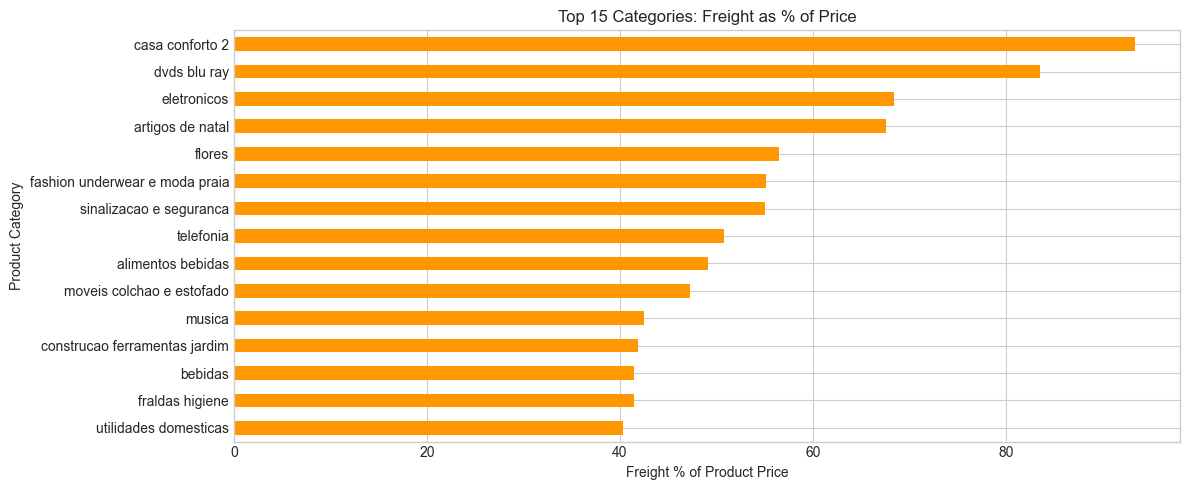

In [75]:
# ---- CHART 24: Freight Percentage by Category ----

freight_pct = df.groupby('product_category_name')['freight_pct'].mean().sort_values().tail(15)
plt.figure(figsize=(12, 5))
freight_pct.plot(kind='barh',color='#FF9800')
plt.title('Top 15 Categories: Freight as % of Price')
plt.xlabel('Freight % of Product Price')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

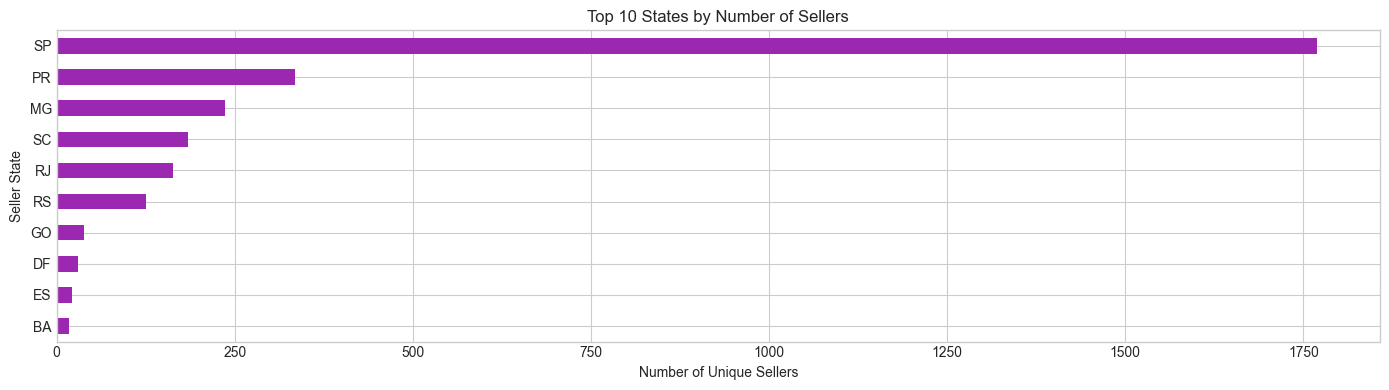

In [74]:
# ---- CHART 25: Seller State Distribution ----

seller_state = df.groupby('seller_state')['seller_id'].nunique().sort_values().tail(10)
plt.figure(figsize=(14, 4))
seller_state.plot(kind='barh',color='#9C27B0')
plt.title('Top 10 States by Number of Sellers')
plt.xlabel('Number of Unique Sellers')
plt.ylabel('Seller State')
plt.tight_layout()
plt.show()



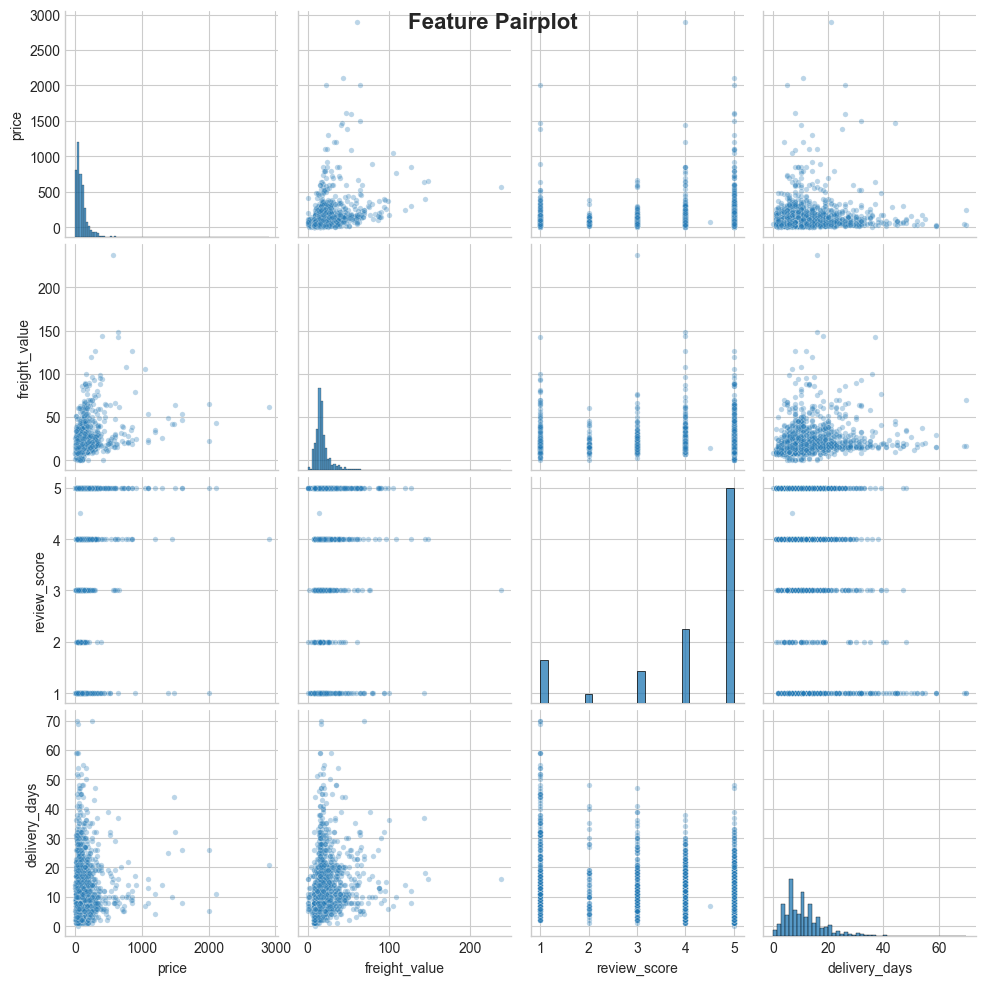

In [47]:
sample_pair = df[['price', 'freight_value', 'review_score', 'delivery_days']].sample(2000, random_state=42).dropna()
g = sns.pairplot(sample_pair,diag_kind='hist',plot_kws={'alpha': 0.3, 's': 15},height=2.5)
g.fig.suptitle('Feature Pairplot', fontsize=16, fontweight='bold')
plt.show()

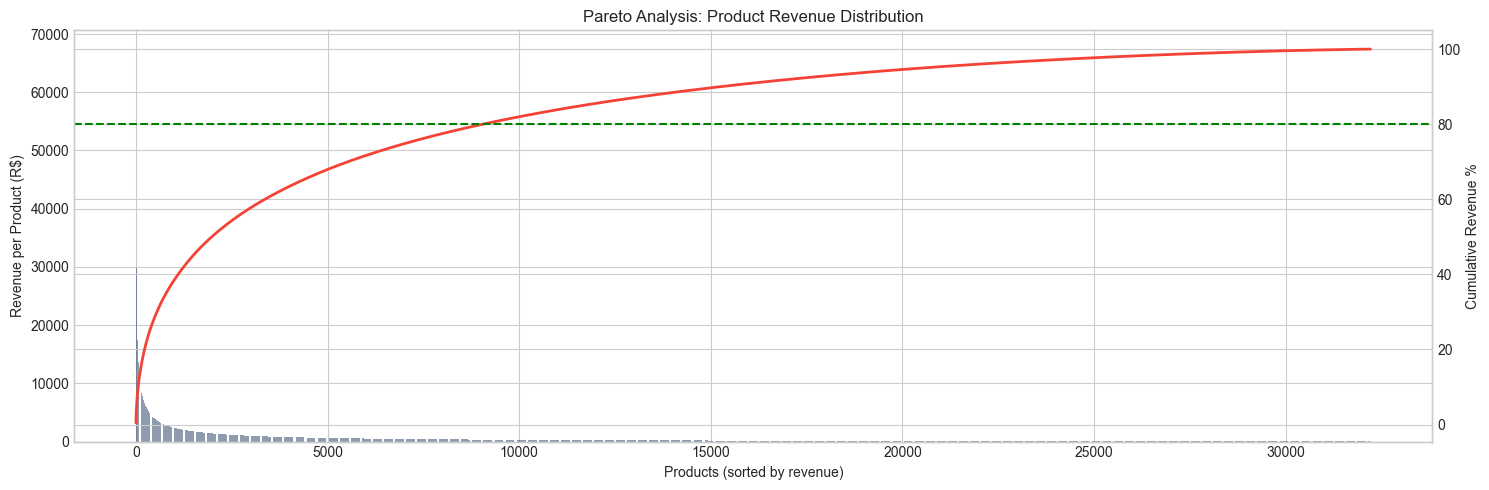

In [73]:
# ---- PARETO ANALYSIS ----
"""
10.3 Pareto Analysis (80/20 Rule)
Do 20% of products generate 80% of revenue?
"""
# 1️⃣ Total revenue per product
product_rev = df.groupby('product_id')['total_price'].sum().sort_values(ascending=False).reset_index()
# 2️⃣ Cumulative revenue
product_rev['cumulative_revenue'] = product_rev['total_price'].cumsum()
# 3️⃣ Cumulative percentage of revenue
product_rev['cumulative_pct'] = ( product_rev['cumulative_revenue'] / product_rev['total_price'].sum() * 100)
# 4️⃣ Product percentage (rank distribution)
product_rev['product_pct'] = ((np.arange(1, len(product_rev) + 1)) / len(product_rev) * 100)



# ---- CHART 26: Pareto Chart ----
fig, ax1 = plt.subplots(figsize=(15, 5))
# 1️⃣ Bar chart (Revenue)
ax1.bar(range(len(product_rev)),product_rev['total_price'],color='#1E3A5F',alpha=0.5)
ax1.set_ylabel('Revenue per Product (R$)')
# 2️⃣ Line chart (Cumulative %)
ax2 = ax1.twinx()
ax2.plot(range(len(product_rev)),product_rev['cumulative_pct'],color='#F44336',linewidth=2)
# 3️⃣ 80% line
ax2.axhline(80, color='green', linestyle='--')
ax2.set_ylabel('Cumulative Revenue %')
# 4️⃣ Titles
ax1.set_title('Pareto Analysis: Product Revenue Distribution')
ax1.set_xlabel('Products (sorted by revenue)')
plt.tight_layout()
plt.show()

In [67]:
if 'cohort_month' in df.columns:df = df.drop('cohort_month', axis=1)
# ---- COHORT ANALYSIS ----
df = df.merge(cohort_df, on='customer_unique_id', how='left')
df = df.drop(columns=[col for col in ['cohort_month'] if col in df.columns])
df = df.merge(cohort_df, on='customer_unique_id', how='left')
df = df.copy()

# 1️⃣ remove old cohort_month (important)
df = df.drop(columns=['cohort_month'], errors='ignore')
# 2️⃣ create cohort again
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
cohort_df = df.groupby('customer_unique_id')['order_month'].min().reset_index()
cohort_df.columns = ['customer_unique_id', 'cohort_month']
# 3️⃣ merge cleanly
df = df.merge(cohort_df, on='customer_unique_id', how='left')



In [68]:
# ---- COHORT ANALYSIS ----
# 1️⃣ Cohort index (months difference)
df['cohort_index'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n if hasattr(x, 'n') else 0)
# 2️⃣ Cohort table
cohort_data = df.groupby(['cohort_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index()
# 3️⃣ Pivot table
cohort_pivot = cohort_data.pivot(index='cohort_month',columns='cohort_index',values='customer_unique_id')
# 4️⃣ Retention (%)
cohort_size = cohort_pivot.iloc[:, 0]retention = cohort_pivot.divide(cohort_size, axis=0) * 100


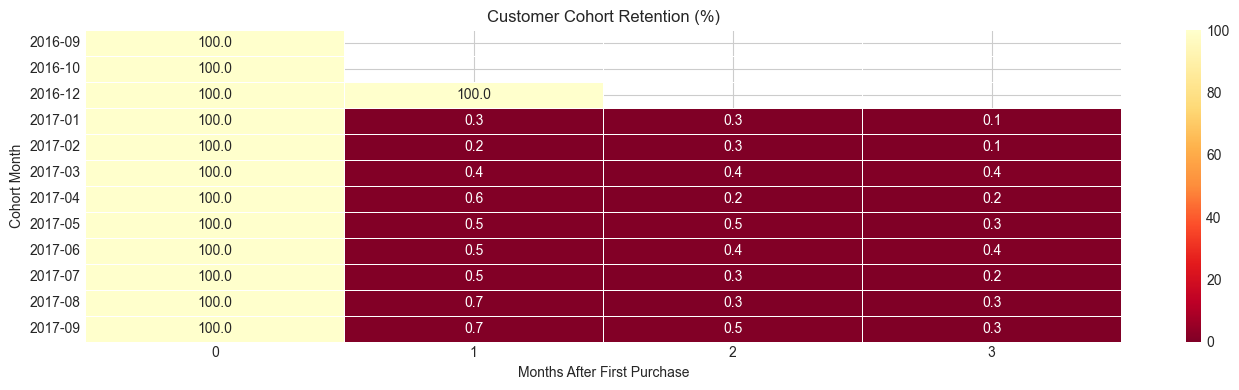

In [71]:
# ---- CHART 27: Cohort Retention Heatmap ----
plt.figure(figsize=(14, 4))
sns.heatmap(retention.iloc[:12, :4],annot=True,fmt='.1f',cmap='YlOrRd_r',linewidths=0.5,vmin=0,vmax=100)
plt.title('Customer Cohort Retention (%)')
plt.xlabel('Months After First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

# 📌 Insight: Very low retention rates (~3%)
# indicates most customers are one-time buyers.
# Major opportunity for loyalty programs.

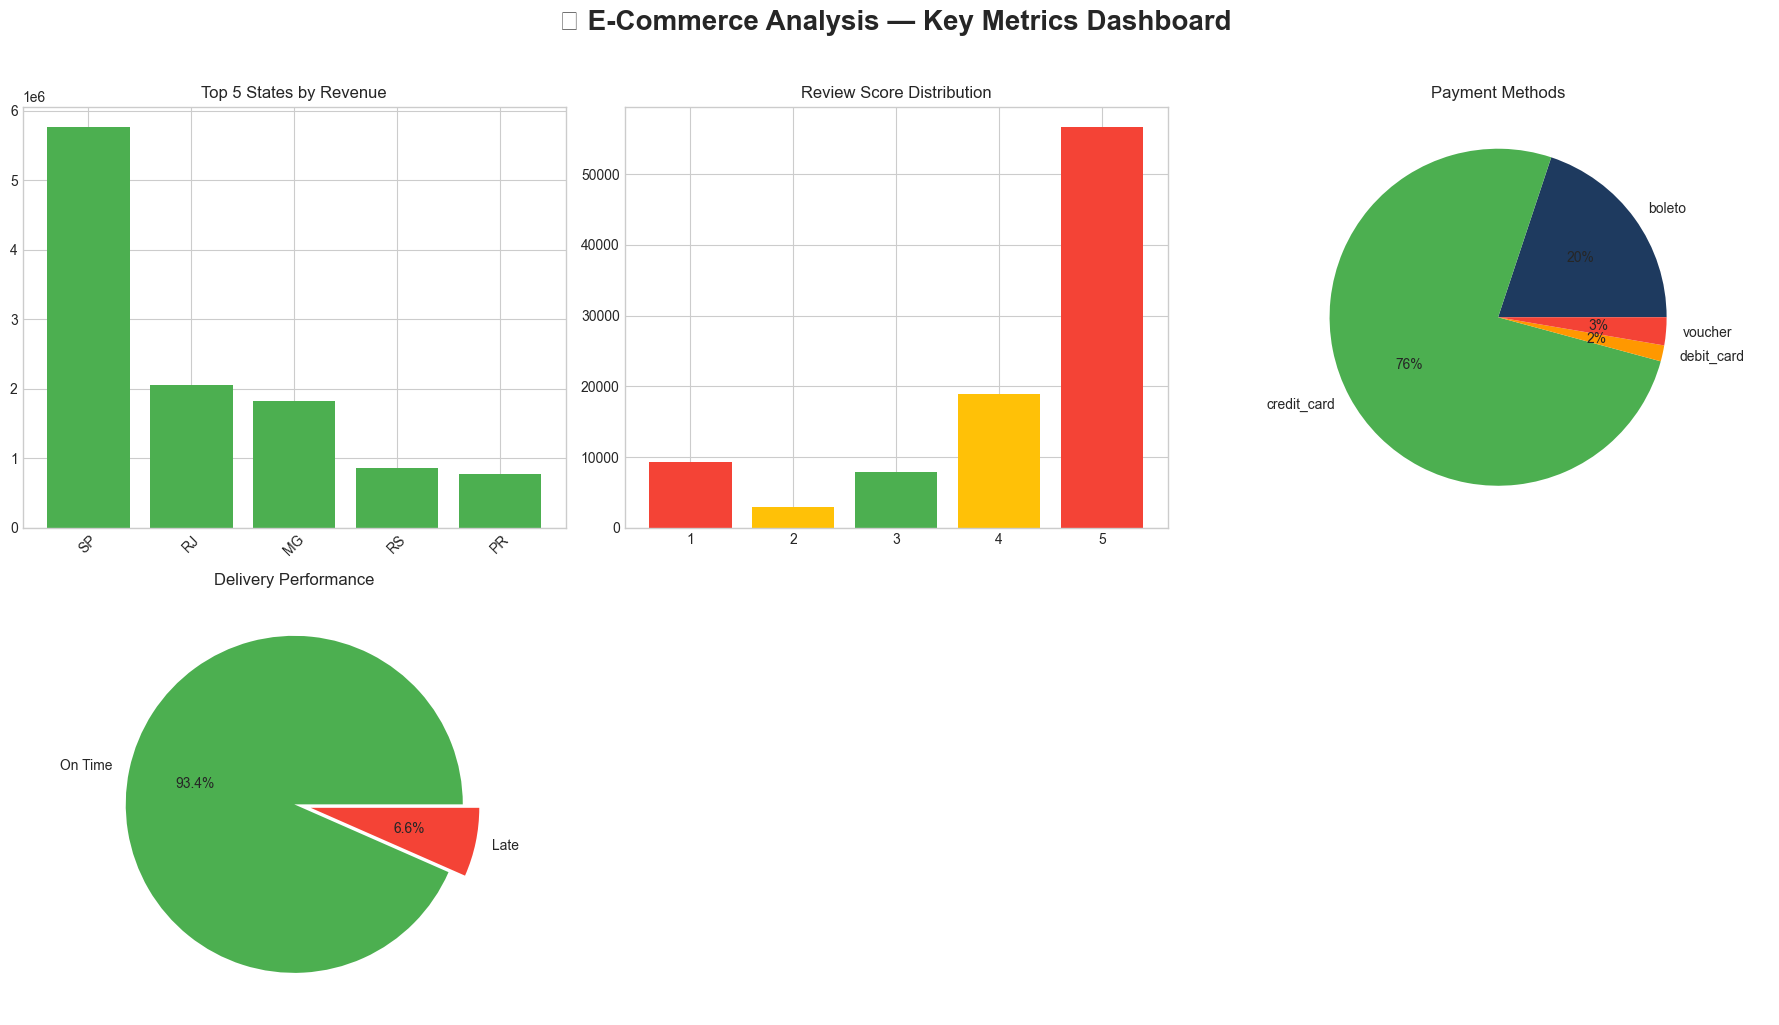

In [95]:
#10.4 Key Metrics Summary

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 E-Commerce Analysis — Key Metrics Dashboard',fontsize=20,fontweight='bold',y=1.02)

# 1️⃣ Top 5 States by Revenue
top5_states = df.groupby('customer_state')['total_price'].sum().nlargest(5)
axes[0, 0].bar(top5_states.index, top5_states.values, color='#4CAF50')
axes[0, 0].set_title('Top 5 States by Revenue')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2️⃣ Review Distribution
rev_dist = df.groupby('order_id')['review_score'].first().value_counts().sort_index()
axes[0, 1].bar(rev_dist.index,rev_dist.values,color=['#F44336', '#FF9800', '#FFC107', '#8BC34A', '#4CAF50'])
axes[0, 1].set_title('Review Score Distribution')

# 3️⃣ Payment Methods
pay = df.groupby('payment_type')['order_id'].nunique()
axes[0, 2].pie(pay,labels=pay.index,autopct='%1.0f%%',colors=['#1E3A5F', '#4CAF50', '#FF9800', '#F44336'])
axes[0, 2].set_title('Payment Methods')

# 4️⃣ Delivery Performance
late = df['is_late'].value_counts()
axes[1, 0].pie(late,labels=['On Time', 'Late'],autopct='%1.1f%%',colors=['#4CAF50', '#F44336'],explode=(0, 0.1))
axes[1, 0].set_title('Delivery Performance')

# 5️⃣ Hide unused plots (important fix)
axes[1, 1].axis('off')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


In [ ]:

#11. Key Findings & Business Recommendations

#📌 Key Findings:
#1. Revenue Growth: Revenue grew significantly from 2017 to 2018, with November showing highest sales (Black Friday)
#2. Geographic Concentration: São Paulo (SP) accounts for ~40% of all revenue — highly concentrated market
#3. Delivery Impact: Late deliveries reduce review scores by ~60% (avg 4.3 on-time vs 2.5 late)
#4. Customer Retention**: ~97% of customers are one-time buyers — massive retention problem
#5. Payment Preference: Credit card dominates (74%), with average 3-4 installments
#6. Pareto Ef: Top 20% of products generate ~75% of revenue
#7. Shipping Costs: Some categories have freight costs that are 30-50% of product price
#8. Peak Hours: Most orders between 10 AM - 4 PM on weekdays

#💡 Business Recommendations:
#1. Loyalty Program: Implement rewards program to improve retention (currently 97% one-time buyers)
#2. Delivery Optimization: Focus on reducing late deliveries in northern states — directly impacts reviews
#3. Geographic Expansion: Invest marketing in high-potential states beyond SP
#4. Freight Optimization: Negotiate better shipping rates for heavy/bulky products
#5. Product Strategy: Focus on top 20% revenue-generating products, evaluate underperforming categories
#6. Seasonal Strategy: Prepare inventory and marketing for peak months (Nov, Mar, May)
"""